## A Lie-group demonstration : where the spin comes from


### 1. The group, its tangent space, and its algebra

$$
SO(3) = \left\{\, R \in \mathbb{R}^{3\times 3} \;:\; R^\top R = I_3,\ \det R = +1 \,\right\}
$$

The constraint $R^\top R = I$ is a *symmetric* matrix equation, hence only $6$ independent scalar equations on the $9$ entries : $SO(3)$ is a smooth compact manifold of dimension $9 - 6 = 3$ (two degrees of freedom to point, one to roll), and $\det R = +1$ selects the connected component of the identity.

**The tangent space at the identity.** Take any smooth curve $t \mapsto R(t) \in SO(3)$ with $R(0) = I$, and differentiate the constraint :

$$
\frac{d}{dt}\left(R^\top R\right) = \dot R^\top R + R^\top \dot R = 0
\quad \overset{t = 0}{\Longrightarrow} \quad
A^\top + A = 0, \qquad A := \dot R(0).
$$

The velocity of *any* motion through the identity is an **antisymmetric** matrix, and conversely every antisymmetric matrix is such a velocity. The tangent space is therefore

$$
\mathfrak{so}(3) = \left\{ A \in \mathbb{R}^{3\times3} : A^\top = -A \right\},
$$

a $3$-dimensional vector space, as the dimension count predicted. A canonical basis is

$$
J_x = \begin{pmatrix} 0&0&0\\ 0&0&-1\\ 0&1&0 \end{pmatrix}, \qquad
J_y = \begin{pmatrix} 0&0&1\\ 0&0&0\\ -1&0&0 \end{pmatrix}, \qquad
J_z = \begin{pmatrix} 0&-1&0\\ 1&0&0\\ 0&0&0 \end{pmatrix},
\qquad (J_a)_{bc} = -\varepsilon_{abc},
$$

and these are nothing but cross products : $J_a v = e_a \times v$, i.e. the map $\hat w$ defined by $\hat w\, v = w \times v$. *An infinitesimal rotation is a cross product with the angular velocity*, the familiar $\dot v = \omega \times v$.

**Back to the group : the exponential map.** The linear ODE $\dot R = A R$, $R(0) = I$, has the unique solution $R(t) = e^{tA} = \sum_k t^k A^k / k!$, and it stays inside the group :

$$
\left(e^{tA}\right)^\top e^{tA} = e^{tA^\top} e^{tA} = e^{-tA}e^{tA} = I,
\qquad \det e^{tA} = e^{t\,\mathrm{tr}\,A} = e^{0} = 1 .
$$

For a unit axis $n$ and an angle $\theta$, the identity $\hat n^3 = -\hat n$ lets one resum the series into **Rodrigues' formula**

$$
e^{\theta \hat n} = I + \sin\theta \; \hat n + (1 - \cos\theta)\; \hat n^2 ,
$$

and Euler's rotation theorem states that $\exp : \mathfrak{so}(3) \to SO(3)$ is *surjective* : every rotation is a single rotation about a single axis.

**Where the 2D case lives inside the 3D one.** For a *fixed* axis, $e^{sA}e^{tA} = e^{(s+t)A}$ : the rotations about one axis form an abelian one-parameter subgroup isomorphic to $SO(2)$. This is exactly the setting of the 2D spectrangular decomposition — one axis, one angle, everything commutes, and the phase is a genuine group coordinate. The entire difficulty of the 3D case is that *one-parameter subgroups generated by different axes do not commute with each other*.

In [1]:
import numpy as np
from scipy.linalg import expm, logm

np.set_printoptions(precision=4, suppress=True)

def hat(w):
    """The so(3) isomorphism  w -> w^,  with  w^ v = w x v  (an antisymmetric matrix)."""
    wx, wy, wz = w
    return np.array([[  0., -wz,  wy],
                     [ wz,   0., -wx],
                     [-wy,  wx,   0.]])

J = [hat(e) for e in np.eye(3)]                 # J[0] = Jx, J[1] = Jy, J[2] = Jz
bracket = lambda A, B: A @ B - B @ A            # the Lie bracket
R = lambda axis, t: expm(t * J[axis])           # one-parameter subgroup exp(t J_a)

print("Jx =\n", J[0], "\n\nJy =\n", J[1], "\n\nJz =\n", J[2], "\n")

# (i) the tangent space at the identity really is made of antisymmetric matrices
print("antisymmetry  ||J^T + J||      :", max(np.abs(Ja.T + Ja).max() for Ja in J))

# (ii) the exponential of an antisymmetric matrix really lands back in SO(3)
Rt = R(2, 0.7)
print("||R^T R - I||  ,  det R        :", np.abs(Rt.T @ Rt - np.eye(3)).max(), ",", np.linalg.det(Rt))

# (iii) Rodrigues' formula, i.e. the resummation allowed by  n^3 = -n
rodrigues = np.eye(3) + np.sin(.7) * J[2] + (1 - np.cos(.7)) * (J[2] @ J[2])
print("Rodrigues residual             :", np.abs(Rt - rodrigues).max())

# (iv) the structure constants   [J_a, J_b] = eps_abc J_c
for (a, b, c), name in zip([(0, 1, 2), (1, 2, 0), (2, 0, 1)],
                           ["[Jx,Jy] = Jz", "[Jy,Jz] = Jx", "[Jz,Jx] = Jy"]):
    print(f"{name}                   : residual {np.abs(bracket(J[a], J[b]) - J[c]).max():.1e}")

# (v) the Jacobi identity -- the infinitesimal shadow of associativity
jacobi = sum(bracket(J[a], bracket(J[b], J[c])) for a, b, c in [(0, 1, 2), (1, 2, 0), (2, 0, 1)])
print("Jacobi residual                :", np.abs(jacobi).max())

# (vi) same axis => commuting (an abelian SO(2) subgroup) ; different axes => not
print("||Rz(.3)Rz(.7) - Rz(.7)Rz(.3)|| :", np.abs(R(2, .3) @ R(2, .7) - R(2, .7) @ R(2, .3)).max())
print("||Rz(.3)Ry(.7) - Ry(.7)Rz(.3)|| :", np.abs(R(2, .3) @ R(1, .7) - R(1, .7) @ R(2, .3)).max())

Jx =
 [[ 0. -0.  0.]
 [ 0.  0. -1.]
 [-0.  1.  0.]] 

Jy =
 [[ 0. -0.  1.]
 [ 0.  0. -0.]
 [-1.  0.  0.]] 

Jz =
 [[ 0. -1.  0.]
 [ 1.  0. -0.]
 [-0.  0.  0.]] 

antisymmetry  ||J^T + J||      : 0.0
||R^T R - I||  ,  det R        : 1.1102230246251565e-16 , 1.0
Rodrigues residual             : 1.1102230246251565e-16
[Jx,Jy] = Jz                   : residual 0.0e+00
[Jy,Jz] = Jx                   : residual 0.0e+00
[Jz,Jx] = Jy                   : residual 0.0e+00
Jacobi residual                : 0.0
||Rz(.3)Rz(.7) - Rz(.7)Rz(.3)|| : 1.1102230246251565e-16
||Rz(.3)Ry(.7) - Ry(.7)Rz(.3)|| : 0.19037934406737272


In [2]:
# so(3) : the velocity of any motion through the identity is a cross product
from spectrospherics import plot_tangent_space

plot_tangent_space().servable()
# plot_tangent_space().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] Column
            [0] FloatSlider(end=180, name='axis azimuth (°)', start=-180, value=35)
            [1] FloatSlider(end=90, name='axis elevation (°)', start=-90, value=40)
            [2] FloatSlider(end=6.283185307179586, name='time t  (angle swept, ..., step=0.01, value=1.1)
        [1] Column
            [0] FloatSlider(end=180, name='point v₀ azimuth (°)', start=-180, value=-60)
            [1] FloatSlider(end=90, name='point v₀ elevation (°)', start=-90, value=10)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

In [3]:
# exp : so(3) -> SO(3), Rodrigues' formula drawn term by term
from spectrospherics import plot_exponential_map

plot_exponential_map().servable()
# plot_exponential_map().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] Column
            [0] FloatSlider(end=180, name='axis azimuth (°)', start=-180, value=30)
            [1] FloatSlider(end=90, name='axis elevation (°)', start=-90, value=45)
            [2] FloatSlider(end=6.283185307179586, name='angle θ (rad)', step=0.01, value=1.2)
        [1] Column
            [0] FloatSlider(end=180, name='vector v azimuth (°)', start=-180, value=-70)
            [1] FloatSlider(end=90, name='vector v elevation (°)', start=-90, value=5)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

### 2. The bracket, computed by hand

Multiply the two generators in both orders — each product only picks a row and a column, so it can be done by eye :

$$
J_x J_y = \begin{pmatrix} 0&0&0\\ 1&0&0\\ 0&0&0\end{pmatrix},
\qquad
J_y J_x = \begin{pmatrix} 0&1&0\\ 0&0&0\\ 0&0&0\end{pmatrix}.
$$

Neither product is antisymmetric — the algebra is not stable under the matrix product — but their **difference** is :

$$
[J_x, J_y] \;:=\; J_xJ_y - J_yJ_x \;=\; \begin{pmatrix} 0&-1&0\\ 1&0&0\\ 0&0&0\end{pmatrix} \;=\; J_z .
$$

Coordinate-free, the same computation reads : since $\hat a\, \hat b\, c = a \times (b \times c)$, the Jacobi identity of the cross product gives

$$
[\hat a, \hat b]\, c = a \times (b \times c) - b \times (a \times c) = (a \times b) \times c
\qquad \Longrightarrow \qquad
[\hat a, \hat b] = \widehat{a \times b},
$$

so that $\left(\mathfrak{so}(3), [\cdot,\cdot]\right) \cong \left(\mathbb{R}^3, \times\right)$ as Lie algebras, and cyclically

$$
[J_a, J_b] = \varepsilon_{abc} J_c .
$$

The bracket is bilinear, antisymmetric ($[A,B] = -[B,A]$, hence $[A,A]=0$), and satisfies the Jacobi identity $[A,[B,C]] + [B,[C,A]] + [C,[A,B]] = 0$. Those three axioms *are* the definition of a Lie algebra, and the Jacobi identity is the infinitesimal shadow of the associativity of the group product. The numbers $\varepsilon_{abc}$ are the **structure constants** : they encode the group multiplication to second order. A connected Lie group is abelian **if and only if** all its structure constants vanish. Those of $SO(3)$ do not, and that single fact generates everything below.

In [4]:
# [a^, b^] = (a x b)^ : the bracket, and the price of swapping two rotations
from spectrospherics import plot_bracket

plot_bracket().servable()
# plot_bracket().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] Column
            [0] FloatSlider(end=180, name='a : azimuth (°)', start=-180)
            [1] FloatSlider(end=90, name='a : elevation (°)', start=-90)
            [2] FloatSlider(end=3.141592653589793, name='‖a‖  (rotation angle, ..., step=0.01, value=1.0)
        [1] Column
            [0] FloatSlider(end=180, name='b : azimuth (°)', start=-180, value=90)
            [1] FloatSlider(end=90, name='b : elevation (°)', start=-90)
            [2] FloatSlider(end=3.141592653589793, name='‖b‖  (rotation angle, ..., step=0.01, value=1.0)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

### 3. The demonstration : a closed loop of commands leaves an open rotation

Take two small rotations, $A = \varepsilon J_x$ and $B = \delta J_y$ with $\varepsilon, \delta = O(\eta)$, and perform the **group commutator** — go, go, come back, come back :

$$
K(\varepsilon, \delta) \;=\; \underbrace{e^{A}}_{R_x(\varepsilon)} \; \underbrace{e^{B}}_{R_y(\delta)} \; \underbrace{e^{-A}}_{R_x(-\varepsilon)} \; \underbrace{e^{-B}}_{R_y(-\delta)} .
$$

In the space of *commands* nothing at all happened : the four instructions sum to $\varepsilon x + \delta y - \varepsilon x - \delta y = 0$. Let us ask the group what it thinks. Expand every factor to second order, $e^{X} = I + X + \tfrac12 X^2 + O(\eta^3)$ :

$$
e^{A} e^{B} = I + \underbrace{(A + B)}_{S} + \underbrace{\tfrac12 A^2 + AB + \tfrac12 B^2}_{T} + O(\eta^3),
\qquad
e^{-A} e^{-B} = I - S + T + O(\eta^3),
$$

the second expansion following from the first under $A \mapsto -A,\, B \mapsto -B$, which flips $S$ and leaves $T$ unchanged. Multiplying the two and keeping everything up to $O(\eta^2)$, the first-order terms cancel and

$$
K = (I + S + T)(I - S + T) = I + 2T - S^2 + O(\eta^3).
$$

Now

$$
2T = A^2 + 2AB + B^2, \qquad S^2 = (A+B)^2 = A^2 + AB + BA + B^2,
$$

the squares cancel, and what survives is precisely the failure of $A$ and $B$ to commute :

$$
\boxed{\;\;K(\varepsilon,\delta) \;=\; I + AB - BA + O(\eta^3) \;=\; I + [A, B] + O(\eta^3) \;=\; I + \varepsilon\delta \, J_z + O(\eta^3). \;\;}
$$

Since $e^{\varepsilon\delta J_z} = I + \varepsilon\delta J_z + O(\eta^4)$, this is exactly

$$
R_x(\varepsilon)\,R_y(\delta)\,R_x(-\varepsilon)\,R_y(-\delta) \;=\; R_z(\varepsilon\delta) \; + \; O(\eta^3) :
$$

**a closed round trip in $x$ and $y$ does not close — it leaves a residual rotation about the third axis, a spin, whose angle is the signed area $\varepsilon\delta$ swept in the command plane.** The Lie bracket is therefore not an analogy for non-commutativity : it *is* its leading term, and the residual is proportional to an area, not to a length.

Three refinements, all verified numerically below.

**(a) The next order.** The Baker–Campbell–Hausdorff series gives the correction

$$
\log K = [A,B] + \tfrac12 \left[A + B, [A,B]\right] + O(\eta^4)
= \varepsilon\delta \, J_z \;+\; \tfrac12 \varepsilon\delta^2 \, J_x \;-\; \tfrac12 \varepsilon^2\delta \, J_y \;+\; O(\eta^4),
$$

so the residual axis is tilted away from $\hat z$ by $O(\eta)$ and becomes purely $\hat z$ only in the limit.

**(b) An exact statement.** The bracket is not merely an approximation, it is a limit :

$$
\lim_{n \to \infty} \left( e^{A/n} e^{B/n} e^{-A/n} e^{-B/n} \right)^{n^2} = e^{[A,B]} .
$$

Shrink the loop by $n$ — its area drops as $n^{-2}$ — and drive around it $n^2$ times : one recovers *exactly* $R_z(\varepsilon\delta)$.

**(c) Equivalent formulations.**

$$
[A,B] \;=\; \left.\frac{\partial^2}{\partial s\, \partial t}\right|_{s=t=0} e^{sA}e^{tB}e^{-sA}e^{-tB}
\;=\; \left.\frac{d}{ds}\right|_{s=0} e^{sA} B\, e^{-sA} .
$$

The second one, the adjoint action $\mathrm{Ad}_{e^{sA}} B = e^{sA} B e^{-sA} = B + s[A,B] + \tfrac{s^2}{2}[A,[A,B]] + \dots$, is the operational reading of the whole business : **after an $x$-turn, "the $y$ axis" is no longer the same axis**. Rotating the *generator* is what makes the ordering matter — and the composition law $\log\left(e^Ae^B\right) = A + B + \tfrac12[A,B] + \tfrac1{12}\left([A,[A,B]] + [B,[B,A]]\right) - \dots$ says the same thing about chaining two commands.

In [5]:
def loop(eps, dlt):
    """The group commutator  K(eps, dlt) = Rx(eps) Ry(dlt) Rx(-eps) Ry(-dlt)."""
    return R(0, eps) @ R(1, dlt) @ R(0, -eps) @ R(1, -dlt)

def rotvec(M):
    """axis x angle of a rotation, read off  log M  in so(3)."""
    w = logm(M).real
    return np.array([w[2, 1], w[0, 2], w[1, 0]])

hdr = (f"{'eps=dlt':>8} {'|log K|':>11} {'eps*dlt':>11} {'ratio':>8} {'axis.z':>8}"
       f" {'|logK-[A,B]|':>14} {'|logK-BCH3|':>13}")
print(hdr); print("-" * len(hdr))
for e in [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]:
    A, B = e * J[0], e * J[1]
    K = loop(e, e)
    w = rotvec(K); angle = np.linalg.norm(w)
    order2 = bracket(A, B)                                  # [A,B]            = O(eta^2)
    order3 = order2 + 0.5 * bracket(A + B, order2)          # + 1/2[A+B,[A,B]] = O(eta^3)
    print(f"{e:8.3f} {angle:11.3e} {e*e:11.3e} {angle/e**2:8.5f} {w[2]/angle:8.5f}"
          f" {np.abs(logm(K).real - order2).max():14.2e}"
          f" {np.abs(logm(K).real - order3).max():13.2e}")

# the two error columns fall like eta^3 and eta^4 : the expansion of section 3 is exact
# order by order, and the ratio column converges to 1 -> the residual angle IS eps*dlt.

eps, dlt = 0.3, 0.2
A, B = eps * J[0], dlt * J[1]
print(f"\nresidual of the loop for (eps, dlt) = ({eps}, {dlt}) :")
print("   log K                     =", rotvec(loop(eps, dlt)))
print("   [A,B] = eps*dlt * Jz      =", rotvec(expm(bracket(A, B))))
print("   [A,B] + 1/2[A+B,[A,B]]    =", rotvec(expm(bracket(A, B) + 0.5 * bracket(A + B, bracket(A, B)))))

print("\nexact statement -- the n^2-th power of the shrinking loop converges to exp([A,B]) :")
for n in [1, 2, 4, 8, 16, 32, 64, 128]:
    Kn = np.linalg.matrix_power(loop(eps / n, dlt / n), n * n)
    print(f"   n = {n:4d}    ||K(eps/n, dlt/n)^(n^2) - exp(eps*dlt Jz)|| = "
          f"{np.abs(Kn - expm(eps * dlt * J[2])).max():.3e}")

 eps=dlt     |log K|     eps*dlt    ratio   axis.z   |logK-[A,B]|   |logK-BCH3|
-------------------------------------------------------------------------------
   0.500   2.450e-01   2.500e-01  0.97995  0.94055       5.88e-02      1.96e-02
   0.200   3.987e-02   4.000e-02  0.99669  0.99008       3.96e-03      5.28e-04
   0.100   9.992e-03   1.000e-02  0.99917  0.99751       4.99e-04      3.32e-05
   0.050   2.499e-03   2.500e-03  0.99979  0.99938       6.25e-05      2.08e-06
   0.020   4.000e-04   4.000e-04  0.99997  0.99990       4.00e-06      5.33e-08
   0.010   1.000e-04   1.000e-04  0.99999  0.99998       5.00e-07      3.33e-09

residual of the loop for (eps, dlt) = (0.3, 0.2) :
   log K                     = [ 0.0059 -0.0089  0.0587]
   [A,B] = eps*dlt * Jz      = [0.   0.   0.06]
   [A,B] + 1/2[A+B,[A,B]]    = [ 0.006 -0.009  0.06 ]

exact statement -- the n^2-th power of the shrinking loop converges to exp([A,B]) :
   n =    1    ||K(eps/n, dlt/n)^(n^2) - exp(eps*dlt Jz)|| = 9.0

In [6]:
# the demonstration itself : a closed loop of commands, an open rotation
from spectrospherics import plot_commutator_loop

plot_commutator_loop().servable()
# plot_commutator_loop().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] Column
            [0] FloatSlider(end=1.5, name='ε  : x-leg (rad)', step=0.01, value=0.6)
            [1] FloatSlider(end=1.5, name='δ  : y-leg (rad)', step=0.01, value=0.6)
            [2] IntSlider(end=12, name='subdivision n  (loop /n, ..., start=1, value=1)
        [1] Column
            [0] FloatSlider(end=180, name='test direction :..., start=-180)
            [1] FloatSlider(end=90, name='test direction :..., start=-90)
    [2] Row
        [0] Plotly(Figure)
        [1] Plotly(Figure)
    [3] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
    [4] Markdown(str)

### 4. What this is, geometrically : curvature, holonomy, and why 2D was easy

The loop closes in the command space $\mathbb{R}^3 \simeq \mathfrak{so}(3)$ and fails to close in $SO(3)$ by an amount proportional to the *area* it encloses. That is, verbatim, the definition of **curvature**, and the residual rotation is a **holonomy**.

Concretely, $SO(3)$ fibres over the sphere,

$$
SO(2) \;\hookrightarrow\; SO(3) \;\xrightarrow{\;\pi\;}\; S^2 = SO(3)/SO(2),
\qquad \pi(R) = R\,e_z ,
$$

that is : **pointing** is the base, **roll** $\gamma$ is the fibre — exactly the $(\alpha,\beta)$ versus $\gamma$ split of the Euler convention above. Our commutator loop is a closed rectangle *in the base* (only pointing manoeuvres), and it returns with a non-zero displacement *along the fibre* : pointing generates roll, and no amount of care in the manoeuvre can avoid it. The very same statement in Riemannian language : parallel-transporting a tangent vector around a closed curve on the unit sphere rotates it by the enclosed solid angle (Gauss–Bonnet, with Gaussian curvature $\equiv 1$), and a geodesic rectangle with sides $\varepsilon$ and $\delta$ encloses an area $\simeq \varepsilon\delta$ — the same number as in §3, and not by coincidence. Foucault's pendulum, the falling cat, parallel parking a car, and the Berry / Pancharatnam phase are all instances of this one mechanism.

Two structural consequences, which will haunt any attempt at a 3D magnitude–phase :

- **The roll cannot be legislated away.** A decomposition of the form "direction, and no roll" would be a continuous section $s : S^2 \to SO(3)$ of the fibration, i.e. a continuous choice of a frame attached to each direction — equivalently a nowhere-vanishing tangent vector field on $S^2$, which the hairy ball theorem forbids ($\chi(S^2) = 2 \neq 0$). $SO(3)$ is **not** $S^2 \times SO(2)$ : it is a non-trivial bundle (in fact $SO(3) \cong \mathbb{RP}^3 = S^3/\pm$, whence the double cover by the unit quaternions).
- **2D was easy for a structural reason, not by luck.** $SO(2)$ is one-dimensional, hence abelian : $\mathfrak{so}(2) = \mathbb{R}J$ and $[J,J] = 0$, no structure constants, no curvature, no holonomy. The angle $\varphi$ *is* a global group coordinate, $e^{\alpha J}e^{\beta J} = e^{(\alpha + \beta)J}$, so "shift the phase" is a well-defined, order-free operation, and $|c_n|$ is a complete invariant of the orbit. Nothing of that survives in three dimensions — not because of a bad parametrization, but because $[\cdot,\cdot] \neq 0$.

residual rotation : 20.041 deg   vs   eps*dlt = 20.626 deg
residual axis     : [ 0.2834 -0.2834  0.9162]   (-> z as eps, dlt -> 0)
angular gap between the start and the end direction : 19.211 deg


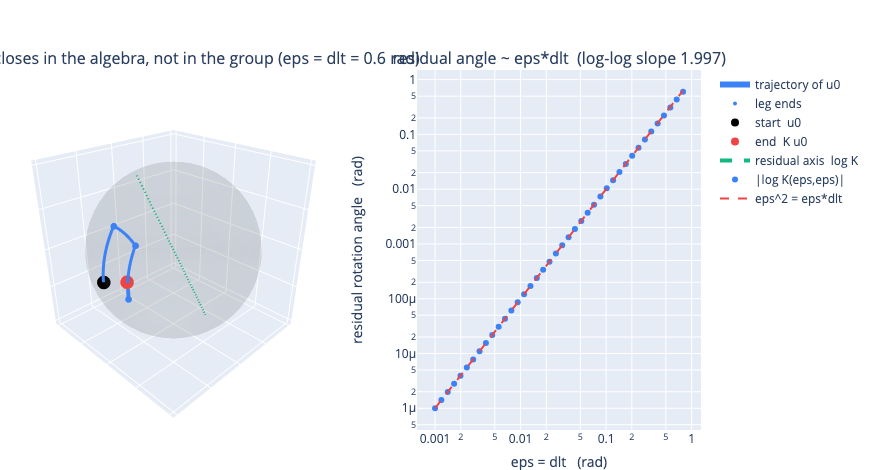

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

EPS = DLT = 0.6                                       # loop legs, in radians
LEGS = [(1, -DLT), (0, -EPS), (1, +DLT), (0, +EPS)]   # rightmost factor applied first
U0 = np.array([1., 0., 0.])                           # the direction dragged around the loop

# (a) the loop, traced continuously on the sphere
C, path, corners = np.eye(3), [], []
for axis, angle in LEGS:
    for s in np.linspace(0, angle, 60):
        path.append(expm(s * J[axis]) @ C @ U0)
    C = expm(angle * J[axis]) @ C
    corners.append(C @ U0)
path, corners = np.array(path), np.array(corners)
K = C                                                 # == loop(EPS, DLT)
w = rotvec(K); residual = np.linalg.norm(w); axis_hat = w / residual

# (b) the eps -> 0 scaling law
es = np.logspace(-3, -0.1, 40)
angles = np.array([np.linalg.norm(rotvec(loop(e, e))) for e in es])
slope = np.polyfit(np.log(es), np.log(angles), 1)[0]

fig = make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45],
                    specs=[[{"type": "scene"}, {"type": "xy"}]],
                    subplot_titles=(f"the loop closes in the algebra, not in the group "
                                    f"(eps = dlt = {EPS} rad)",
                                    f"residual angle ~ eps*dlt  (log-log slope {slope:.3f})"))
u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
fig.add_trace(go.Surface(x=np.cos(u) * np.sin(v), y=np.sin(u) * np.sin(v), z=np.cos(v),
                         opacity=.12, showscale=False, hoverinfo='skip',
                         colorscale=[[0, 'grey'], [1, 'grey']]), row=1, col=1)
fig.add_trace(go.Scatter3d(x=path[:, 0], y=path[:, 1], z=path[:, 2], mode='lines',
                           line=dict(width=6, color='rgb(59,130,246)'),
                           name='trajectory of u0'), row=1, col=1)
fig.add_trace(go.Scatter3d(x=corners[:, 0], y=corners[:, 1], z=corners[:, 2], mode='markers',
                           marker=dict(size=4, color='rgb(59,130,246)'), name='leg ends'), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[U0[0]], y=[U0[1]], z=[U0[2]], mode='markers',
                           marker=dict(size=8, color='black'), name='start  u0'), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[(K @ U0)[0]], y=[(K @ U0)[1]], z=[(K @ U0)[2]], mode='markers',
                           marker=dict(size=8, color='rgb(239,68,68)'), name='end  K u0'), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[-axis_hat[0], axis_hat[0]], y=[-axis_hat[1], axis_hat[1]],
                           z=[-axis_hat[2], axis_hat[2]], mode='lines',
                           line=dict(width=4, color='rgb(16,185,129)', dash='dash'),
                           name='residual axis  log K'), row=1, col=1)
fig.add_trace(go.Scatter(x=es, y=angles, mode='markers', name='|log K(eps,eps)|',
                         marker=dict(size=6, color='rgb(59,130,246)')), row=1, col=2)
fig.add_trace(go.Scatter(x=es, y=es**2, mode='lines', name='eps^2 = eps*dlt',
                         line=dict(color='rgb(239,68,68)', dash='dash')), row=1, col=2)
ax = dict(range=[-1.05, 1.05], showticklabels=False, title='')
fig.update_layout(width=1020, height=470, margin=dict(t=70, b=10, l=0, r=0),
                  scene=dict(xaxis=ax, yaxis=ax, zaxis=ax, aspectmode='cube',
                             camera=dict(eye=dict(x=1.5, y=1.5, z=1.1))))
fig.update_xaxes(type='log', title='eps = dlt   (rad)', row=1, col=2)
fig.update_yaxes(type='log', title='residual rotation angle   (rad)', row=1, col=2)

print(f"residual rotation : {np.degrees(residual):.3f} deg   vs   eps*dlt = {np.degrees(EPS*DLT):.3f} deg")
print(f"residual axis     : {axis_hat}   (-> z as eps, dlt -> 0)")
print(f"angular gap between the start and the end direction : "
      f"{np.degrees(np.arccos(np.clip(U0 @ (K @ U0), -1, 1))):.3f} deg")
fig.show()

In [8]:
# the same residual, as the curvature of the sphere : holonomy = enclosed area
from spectrospherics import plot_parallel_transport

plot_parallel_transport().servable()
# plot_parallel_transport().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] FloatSlider(end=170, name='start colatitude θ₀ (°)', start=5, value=60)
        [1] FloatSlider(end=80, name='Δθ  (°)', start=-80, value=35)
        [2] FloatSlider(end=180, name='Δφ  (°)', start=-180, value=60)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

In [9]:
# no continuous section S^2 -> SO(3) : the roll cannot be legislated away
from spectrospherics import plot_hairy_ball

plot_hairy_ball().servable()
# plot_hairy_ball().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] FloatSlider(end=180, name='reference direction n..., start=-180)
        [1] FloatSlider(end=90, name='reference direction n..., start=-90, value=90)
        [2] FloatSlider(end=80, name='ring around t..., start=5, value=25)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

### 5. The same obstruction, seen by the ambisonic coefficients

Rotations act on fields by $(R \cdot f)(u) = f(R^{-1}u)$ — the inverse is what makes it a left action, $R_1 \cdot (R_2 \cdot f) = (R_1R_2)\cdot f$. Each degree-$\ell$ eigenspace $\mathcal{H}_\ell = \mathrm{span}\{Y_\ell^m\}_{m=-\ell}^{\ell}$ is invariant and irreducible, so that

$$
R \cdot Y_\ell^m = \sum_{m' = -\ell}^{\ell} D^\ell_{m'm}(R)\, Y_\ell^{m'},
\qquad \text{i.e.} \qquad
\mathbf{a}_\ell \;\longmapsto\; D^\ell(R)\, \mathbf{a}_\ell ,
$$

where $D^\ell$ is the **Wigner-D matrix** — the subject of the next notebook. Two facts then do all the work.

- $D^\ell$ is a group homomorphism, so its differential $dD^\ell : \mathfrak{so}(3) \to \mathfrak{gl}(2\ell+1)$ is a **Lie algebra homomorphism** : $dD^\ell([A,B]) = [dD^\ell(A), dD^\ell(B)]$. **The non-commutativity is therefore reproduced verbatim in every degree $\ell$** : there is no order, no basis and no convention in which the problem quietly disappears. Writing $L_a = i\, dD^\ell(J_a)$ (Hermitian, the physicists' convention with $\hbar = 1$), the same relations read $[L_x, L_y] = i L_z$ and cyclic.
- The Casimir element $L^2 = L_x^2 + L_y^2 + L_z^2$ commutes with all the $L_a$, hence by Schur's lemma it is a scalar on an irreducible block : $L^2 = \ell(\ell+1)\,\mathbb{1}$. This is why $D^\ell(R)$ is unitary (orthogonal in the real basis) and why $\Vert \mathbf{a}_\ell \Vert$ is conserved — the invariance already noticed above.

In the $|\ell m\rangle$ basis $L_z$ is diagonal with eigenvalue $m$, so a rotation about $z$ acts as $a_\ell^m \mapsto e^{-i m \alpha} a_\ell^m$ : **that, and only that, is the commuting, 2D-like direction.** In the real basis it reads even more explicitly — the pair $\left(a_\ell^{-m}, a_\ell^{m}\right)$ is rotated by the angle $m\alpha$, one planar rotation per $|m|$, i.e. exactly the spectrangular picture repeated $\ell$ times. A tilt is another story : the ladder operators $L_\pm = L_x \pm i L_y$ obey

$$
[L_z, L_\pm] = \pm L_\pm, \qquad [L_+, L_-] = 2L_z,
\qquad L_\pm \,|\ell, m\rangle = \sqrt{\ell(\ell+1) - m(m\pm1)}\;|\ell, m \pm 1\rangle ,
$$

so a rotation about $y$ genuinely **mixes the orders $m$ inside a degree** (this mixing matrix *is* the Wigner-$d$ matrix $d^\ell_{m'm}(\beta)$), preserving only the total norm.

Now push the demonstration of §3 through $D^\ell$ :

$$
D^\ell\!\left(K(\varepsilon,\delta)\right)
= \mathbb{1} + \varepsilon\delta\; dD^\ell(J_z) + O(\eta^3)
= \mathrm{diag}\left(e^{-i m \varepsilon\delta}\right)_{m = -\ell \dots \ell} + O(\eta^3) .
$$

**After a closed loop of purely pointing manoeuvres, the multiplet comes back re-phased, each order $m$ having picked up a phase proportional to $m$.** The orders precess at $2\ell+1$ different rates, the returned field is not the field one started from, and no scalar "phase" could ever have accounted for it. Only $\ell = 0$ escapes : the omni channel carries the trivial representation, which is why it is the sole genuinely rotation-blind quantity of the expansion.

In [10]:
def angular_momentum(l):
    """The (2l+1)-dimensional irrep of so(3) in the |l,m> basis, ordered m = l ... -l,
    built from the ladder action  L+-|l,m> = sqrt(l(l+1) - m(m+-1)) |l,m+-1>."""
    m = np.arange(l, -l - 1, -1.0)
    d = 2 * l + 1
    Lz = np.diag(m).astype(complex)
    Lp, Lm = np.zeros((d, d), complex), np.zeros((d, d), complex)
    for i in range(d):
        for k in range(d):
            if m[i] == m[k] + 1: Lp[i, k] = np.sqrt(l * (l + 1) - m[k] * (m[k] + 1))
            if m[i] == m[k] - 1: Lm[i, k] = np.sqrt(l * (l + 1) - m[k] * (m[k] - 1))
    return (Lp + Lm) / 2, (Lp - Lm) / 2j, Lz          # Lx, Ly, Lz (Hermitian)

eps, dlt = 0.3, 0.2

for l in [1, 2, 3, 4]:
    Lx, Ly, Lz = angular_momentum(l)
    Jl = [-1j * Lx, -1j * Ly, -1j * Lz]               # anti-Hermitian convention : dD^l(J_a)
    # (i) the representation preserves the bracket -- the very same algebra, in dimension 2l+1
    algebra = max(np.abs(bracket(Jl[a], Jl[b]) - Jl[c]).max()
                  for a, b, c in [(0, 1, 2), (1, 2, 0), (2, 0, 1)])
    # (ii) Casimir L^2 = l(l+1) . 1  (Schur)  =>  ||a_l|| is rotation invariant
    casimir = Lx @ Lx + Ly @ Ly + Lz @ Lz
    # (iii) run the very same commutator loop inside the irrep
    Kl = expm(eps * Jl[0]) @ expm(dlt * Jl[1]) @ expm(-eps * Jl[0]) @ expm(-dlt * Jl[1])
    print(f"l = {l}   (dim {2*l+1})")
    print(f"   ||[dD(Ja),dD(Jb)] - dD(Jc)|| = {algebra:.1e}       "
          f"L^2 = {casimir[0,0].real:.3f} . 1  (l(l+1) = {l*(l+1)}), "
          f"off-diagonal {np.abs(casimir - casimir[0,0] * np.eye(2*l+1)).max():.1e}")
    print(f"   ||D(K) - exp(eps*dlt dD(Jz))|| = {np.abs(Kl - expm(eps * dlt * Jl[2])).max():.1e}     "
          f"unitarity {np.abs(Kl.conj().T @ Kl - np.eye(2*l+1)).max():.1e}")
    print(f"   arg diag D(K) = {np.round(np.angle(np.diag(Kl)), 4)}")
    print(f"   -m eps*dlt    = {np.round(-np.arange(l, -l-1, -1.) * eps * dlt, 4)}\n")

# ---- what that closed pointing loop does to an actual degree-3 multiplet ----
l = 3
Lx, Ly, Lz = angular_momentum(l); Jl = [-1j * Lx, -1j * Ly, -1j * Lz]
Kl = expm(eps * Jl[0]) @ expm(dlt * Jl[1]) @ expm(-eps * Jl[0]) @ expm(-dlt * Jl[1])
a = np.zeros(2 * l + 1, complex); a[0], a[3], a[5] = 1.0, 0.5, -0.8     # orders m = 3, 0, -2
b = Kl @ a
nz = np.abs(a) > 0
print("a closed *pointing* loop applied to a degree-3 multiplet a_3 :")
print("   m                  =", np.arange(l, -l - 1, -1))
print("   |a_m|  before      =", np.round(np.abs(a), 4))
print("   |a_m|  after       =", np.round(np.abs(b), 4), "  <- orders that were empty are now populated")
print("   ||a_3|| before/after =", np.linalg.norm(a), "/", np.linalg.norm(b), "  (Casimir)")
print("   phase drift on the populated orders :", np.round(np.angle(b[nz] / a[nz]), 4),
      "  vs  -m eps*dlt =", np.round(-np.arange(l, -l - 1, -1)[nz] * eps * dlt, 4))

l = 1   (dim 3)
   ||[dD(Ja),dD(Jb)] - dD(Jc)|| = 2.2e-16       L^2 = 2.000 . 1  (l(l+1) = 2), off-diagonal 4.4e-16
   ||D(K) - exp(eps*dlt dD(Jz))|| = 7.5e-03     unitarity 3.3e-16
   arg diag D(K) = [-0.0587  0.      0.0587]
   -m eps*dlt    = [-0.06 -0.    0.06]

l = 2   (dim 5)
   ||[dD(Ja),dD(Jb)] - dD(Jc)|| = 5.6e-16       L^2 = 6.000 . 1  (l(l+1) = 6), off-diagonal 8.9e-16
   ||D(K) - exp(eps*dlt dD(Jz))|| = 1.3e-02     unitarity 1.2e-16
   arg diag D(K) = [-0.1174 -0.0587  0.      0.0587  0.1174]
   -m eps*dlt    = [-0.12 -0.06 -0.    0.06  0.12]

l = 3   (dim 7)
   ||[dD(Ja),dD(Jb)] - dD(Jc)|| = 1.6e-15       L^2 = 12.000 . 1  (l(l+1) = 12), off-diagonal 1.8e-15
   ||D(K) - exp(eps*dlt dD(Jz))|| = 1.8e-02     unitarity 7.8e-16
   arg diag D(K) = [-0.1762 -0.1174 -0.0587  0.      0.0587  0.1174  0.1762]
   -m eps*dlt    = [-0.18 -0.12 -0.06 -0.    0.06  0.12  0.18]

l = 4   (dim 9)
   ||[dD(Ja),dD(Jb)] - dD(Jc)|| = 3.3e-15       L^2 = 20.000 . 1  (l(l+1) = 20), off-diagonal 3.6

In [11]:
# D^l(a,b,g) : a phase along z (2D-like), a genuine mixing along y
from spectrospherics import plot_wigner_mixing

plot_wigner_mixing().servable()
# plot_wigner_mixing().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] IntSlider(end=6, name='degree ℓ', start=1, value=3)
        [1] FloatSlider(end=6.283185307179586, name='α  : yaw about z (rad)', step=0.01, value=0.8)
        [2] FloatSlider(end=3.141592653589793, name='β  : tilt about y (rad)', step=0.01)
        [3] FloatSlider(end=6.283185307179586, name='γ  : roll about z (rad)', step=0.01)
    [2] Plotly(Figure)
    [3] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
    [4] Markdown(str)

In [12]:
# the closed pointing loop of section 3, applied to the ambisonic coefficients
from spectrospherics import plot_loop_rephasing

plot_loop_rephasing().servable()
# plot_loop_rephasing().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] IntSlider(end=6, name='degree ℓ', start=1, value=3)
        [1] FloatSlider(end=1.2, name='ε  : x-leg (rad)', step=0.01, value=0.3)
        [2] FloatSlider(end=1.2, name='δ  : y-leg (rad)', step=0.01, value=0.2)
        [3] IntSlider(end=20, name='number of times t..., start=1, value=1)
    [2] Plotly(Figure)
    [3] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
    [4] Markdown(str)

### 6. The consequence for a 3D magnitude–phase decomposition

A dimension count turns the obstruction into a number. Since $\dim SO(3) = 3$, the orbit $\{D^\ell(R)\,\mathbf{a}_\ell : R \in SO(3)\}$ of a multiplet has dimension at most $3$ inside $\mathbb{R}^{2\ell+1}$. A polar-like decomposition would have to split

$$
\mathbf{a}_\ell \;\longleftrightarrow\; (\text{invariants}) \;\times\; (\text{group coordinates}),
\qquad
\underbrace{2\ell+1}_{\dim \mathcal{H}_\ell} \;=\; \underbrace{(2\ell+1) - \dim \mathcal{O}}_{\text{independent invariants}} \;+\; \underbrace{\dim \mathcal{O}}_{\text{orbit}} ,
$$

with $\dim \mathcal{O} = 3 - \dim(\text{stabiliser})$. Case by case :

- $\ell = 1$ : $\;3 = 1 + 2$. The stabiliser of a dipole is the $SO(2)$ of rolls about its own axis, so the orbit is a $2$-sphere : one invariant (the norm) and a *direction*. This is the only degree that resembles the 2D story — and even here the missing roll is precisely the non-integrable degree of freedom of §4.
- $\ell = 2$ : $\;5 = 2 + 3$. Degree-2 fields are the symmetric traceless $3\times3$ matrices $Q$; their invariants are $\mathrm{tr}\,Q^2$ (the norm) **and** $\mathrm{tr}\,Q^3$, while the group coordinates are the three Euler angles of the eigenframe. Two moduli already, not one.
- $\ell \ge 2$ in general : the generic stabiliser is finite, so there are $2\ell - 2$ independent invariants. The "modulus" of a degree is not a number but a list of $2\ell-2$ numbers, and the "phase" is not an angle but a whole element of $SO(3)$ acting through $D^\ell$ — an element whose coordinates, as $\S3$ showed, do not simply add up.

So the failure observed at the beginning of this notebook is not a lack of ingenuity in choosing a parametrization : it is $[J_x, J_y] = J_z$. The way out is to stop looking for a scalar phase, and to work with the object that actually encodes what a 3D rotation does to a multiplet — the Wigner-$d$ matrix.

In [13]:
# moduli vs group coordinates on the degree-2 multiplet : 5 = 2 + 3
from spectrospherics import plot_orbit_invariants

plot_orbit_invariants().servable()
# plot_orbit_invariants().show()   # <- in browser version

Column
    [0] Markdown(str)
    [1] Row
        [0] Column
            [0] FloatSlider(end=1.5, name='λ₁  (modulus 1)', start=-1.5, step=0.01, value=1.0)
            [1] FloatSlider(end=1.5, name='λ₂  (modulus 2)', start=-1.5, step=0.01, value=-0.3)
        [1] Column
            [0] FloatSlider(end=6.283185307179586, name='α  (group coordinate)', step=0.01)
            [1] FloatSlider(end=3.141592653589793, name='β  (group coordinate)', step=0.01)
            [2] FloatSlider(end=6.283185307179586, name='γ  (group coordinate)', step=0.01)
    [2] Row
        [0] Plotly(Figure)
        [1] Column
            [0] LaTeX(str, renderer='mathjax', styles={'font-size': '15px'}, width=520)
            [1] Markdown(str)

So... how to face all of that? First, we will enter the real core of 3d rotations : the **Wigner d-matrix**. 